## pytorch workflow - Regression model

In [2]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
torch.__version__

'2.10.0+cu128'

### data processing and loading

In [6]:
 ## regression variables
weight = 0.7
bias= 0.3
X = torch.arange(start=0, end=1, step=0.02).unsqueeze(dim=1)
y= weight * X + bias

print(X[:10], y[:10])
print("length X and y :  ",len(X), " | ",len(y))

tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800]]) tensor([[0.3000],
        [0.3140],
        [0.3280],
        [0.3420],
        [0.3560],
        [0.3700],
        [0.3840],
        [0.3980],
        [0.4120],
        [0.4260]])
length X and y :   50  |  50



printing dataset length...
40 40 10 10


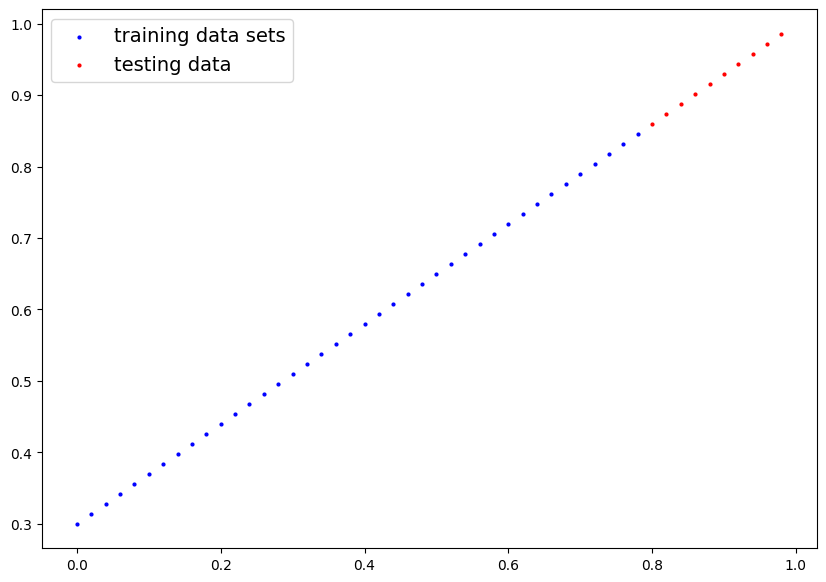

In [3]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
print("\nprinting dataset length...")
print(len(X_train), len(y_train), len(X_test), len(y_test))

def plot_prediction(train_data= X_train, train_labels=y_train, test_data=X_test,
                    test_labels=y_test, predictions=None):
  plt.figure(figsize=(10,7))
  plt.scatter(train_data, train_labels, c='b',s=4, label="training data sets")
  plt.scatter(test_data, test_labels, c='r', s=4, label="testing data")

  if predictions is not None:
    plt.scatter(test_data, predictions, c='g', s=4, label="Predictions")

  plt.legend(prop={"size":14})

plot_prediction();


### 1.build model
### using self custom weight and bias parameter

In [4]:
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weight = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
    ## nn.moduel-> forward() - define computation in model
  def forward(self, x: torch.Tensor) -> torch.Tensor:
      return self.weight * x + self.bias

In [5]:
torch.manual_seed(42)
model0 = LinearRegressionModel()
list(model0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [6]:
model0.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [7]:
## Loss function : backpropogation
loss_fn = nn.L1Loss() ## use for linear problem
## nn.BCELoss - for classification problem
## optimizer : stochastic gradient descent
optimizer = torch.optim.SGD(params=model0.parameters(),lr=0.01)


In [8]:
if torch.cuda.is_available():
  device = "cuda"
"cpu"

'cpu'

### training and evaluation model

In [10]:
epochs = 100
## tracking loss values
epoch_count = []
loss_values =[]
test_loss_values = []
## data in target device , device agnostic code
# X_train = X_train.to(device)
# X_test = X_test.to(device)
# y_train = y_train.to(device)
# y_test = y_test.to(device)

for epoch in range(epochs):
  model0.train()
  y_pred = model0(X_train)          ## forward pass
  loss = loss_fn(y_pred, y_train)   ## calculate the loss
  print(f"loss : {loss}")
  optimizer.zero_grad()             ## optimizer zero grad
  loss.backward()                   ## backpropgation for loss object
  optimizer.step()                  ## gradient descent
  model0.eval()                     ## model evluation ,turn off gradient descent
  with torch.inference_mode():
    test_pred = model0(X_test)
    test_loss = loss_fn(test_pred, y_test)
  if epoch % 10 == 0:
    epoch_count.append(epoch)
    loss_values.append(loss)
    test_loss_values.append(test_loss)
    print(f" epochs {epoch} | Test : {loss} | MAE Test Loss : {test_loss}")
    print(model0.state_dict())



loss : 0.31288138031959534
 epochs 0 | Test : 0.31288138031959534 | MAE Test Loss : 0.48106518387794495
OrderedDict({'weight': tensor([0.3406]), 'bias': tensor([0.1388])})
loss : 0.3013603389263153
loss : 0.28983935713768005
loss : 0.2783183455467224
loss : 0.26679736375808716
loss : 0.2552763521671295
loss : 0.24375534057617188
loss : 0.23223432898521423
loss : 0.22071333229541779
loss : 0.20919232070446014
loss : 0.1976713240146637
 epochs 10 | Test : 0.1976713240146637 | MAE Test Loss : 0.3463551998138428
OrderedDict({'weight': tensor([0.3796]), 'bias': tensor([0.2388])})
loss : 0.18615034222602844
loss : 0.1746293306350708
loss : 0.16310831904411316
loss : 0.1515873372554779
loss : 0.14006635546684265
loss : 0.1285453587770462
loss : 0.11702437698841095
loss : 0.1060912236571312
loss : 0.09681284427642822
loss : 0.08908725529909134
 epochs 20 | Test : 0.08908725529909134 | MAE Test Loss : 0.21729660034179688
OrderedDict({'weight': tensor([0.4184]), 'bias': tensor([0.3333])})
loss :

In [13]:
model0.state_dict()

OrderedDict([('weight', tensor([0.5784])), ('bias', tensor([0.3513]))])

In [11]:
## convert tensor to numpy
np.array(torch.tensor(loss_values).cpu().numpy()), np.array(torch.tensor(test_loss_values).cpu().numpy())

/tmp/ipython-input-3831730094.py:2: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  np.array(torch.tensor(loss_values).cpu().numpy()), np.array(torch.tensor(test_loss_values).cpu().numpy())


(array([0.31288138, 0.19767132, 0.08908726, 0.05314853, 0.04543797,
        0.04167863, 0.03818933, 0.0347609 , 0.03132383, 0.0278874 ],
       dtype=float32),
 array([0.48106518, 0.3463552 , 0.2172966 , 0.14464018, 0.11360953,
        0.09919948, 0.08886633, 0.08059376, 0.07232123, 0.06473556],
       dtype=float32))

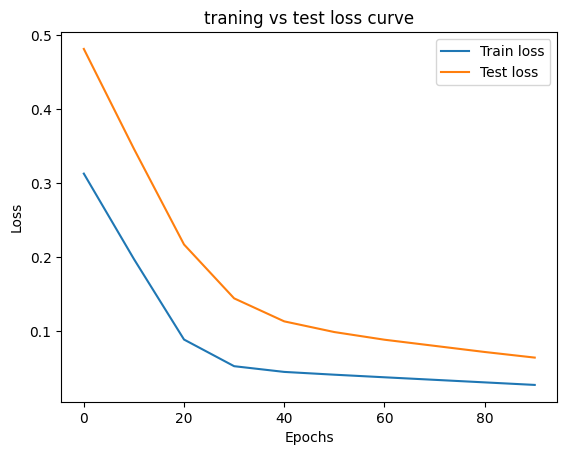

In [12]:
plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label= "Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("traning vs test loss curve")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

### prediction model

In [14]:
## prediction with model
with torch.inference_mode():
  y_pred = model0(X_test)

y_pred, y_test


(tensor([[0.8141],
         [0.8256],
         [0.8372],
         [0.8488],
         [0.8603],
         [0.8719],
         [0.8835],
         [0.8950],
         [0.9066],
         [0.9182]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

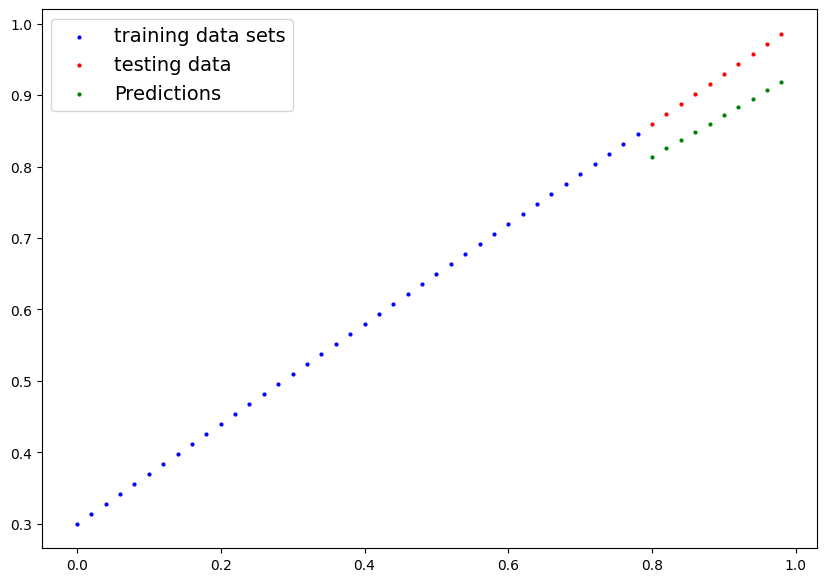

In [15]:
plot_prediction(predictions=y_pred)

### save model

In [16]:
# torch.save()
# torch.load()
# torch.nn.Module.load_state_dict()
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)
MODEL_NAME = "pytorch_workflow_model0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME
print(f"saving model :", {MODEL_SAVE_PATH})
torch.save(obj=model0.state_dict(), f=MODEL_SAVE_PATH)

saving model : {PosixPath('models/pytorch_workflow_model0.pth')}


### loading model

In [17]:
loaded_model0 = LinearRegressionModel()
loaded_model0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [18]:
loaded_model0.state_dict()

OrderedDict([('weight', tensor([0.5784])), ('bias', tensor([0.3513]))])

In [19]:
loaded_model0.eval()
with torch.inference_mode():
  loaded_model_preds = loaded_model0(X_test)
loaded_model_preds

tensor([[0.8141],
        [0.8256],
        [0.8372],
        [0.8488],
        [0.8603],
        [0.8719],
        [0.8835],
        [0.8950],
        [0.9066],
        [0.9182]])

In [20]:
y_pred == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

### 2.build linear model
###using built in nn.Linear() function

In [3]:
if torch.cuda.is_available():
  device = "cuda"
"cpu"
print(f"current device => {device}")

current device => cuda


tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800]]) tensor([[0.3000],
        [0.3140],
        [0.3280],
        [0.3420],
        [0.3560],
        [0.3700],
        [0.3840],
        [0.3980],
        [0.4120],
        [0.4260]])
length X and y :   50  |  50

printing dataset length...
40 40 10 10


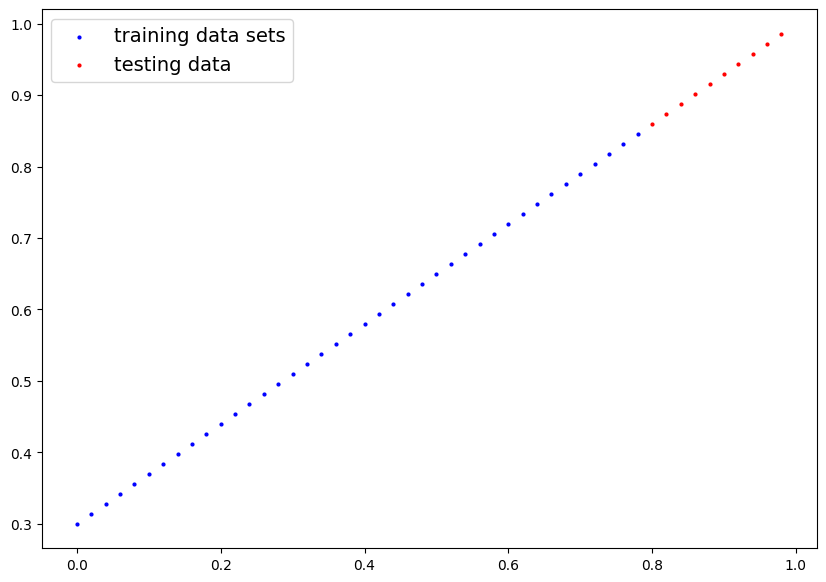

In [18]:
 ## Linear regression variables
weight = 0.7
bias= 0.3
X = torch.arange(start=0, end=1, step=0.02).unsqueeze(dim=1)
y= weight * X + bias

print(X[:10], y[:10])
print("length X and y :  ",len(X), " | ",len(y))

train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
print("\nprinting dataset length...")
print(len(X_train), len(y_train), len(X_test), len(y_test))
def plot_prediction(train_data= X_train, train_labels=y_train, test_data=X_test,
                    test_labels=y_test, predictions=None):
  plt.figure(figsize=(10,7))
  plt.scatter(train_data, train_labels, c='b',s=4, label="training data sets")
  plt.scatter(test_data, test_labels, c='r', s=4, label="testing data")

  if predictions is not None:
    plt.scatter(test_data, predictions, c='g', s=4, label="Predictions")

  plt.legend(prop={"size":14})

plot_prediction();

In [19]:
class LinearRegressionModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear_layer = nn.Linear(in_features=1, out_features=1)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.linear_layer(x)
torch.manual_seed(42)
model1 = LinearRegressionModelV2()
model1, model1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [20]:
X_train[:5], y_train[:5]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560]]))

In [21]:
next(model1.parameters()).device

device(type='cpu')

In [22]:
model1.to(device)
next(model1.parameters()).device

device(type='cuda', index=0)

### training

In [23]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model1.parameters(), lr=0.01)

In [24]:
# training loop
torch.manual_seed(42)
epochs = 100
## data in target device , device agnostic code
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)
for epoch in range(epochs):
  model1.train()
  y_pred = model1(X_train)
  loss = loss_fn(y_pred, y_train)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  model1.eval()
  with torch.inference_mode():
    test_pred = model1(X_test)
    test_loss = loss_fn(test_pred, y_test)
  if epoch % 10 ==0:
    print(f" epochs {epoch} | Test : {loss} | Test Loss : {test_loss}")
    print(model1.state_dict())



 epochs 0 | Test : 0.5551779270172119 | Test Loss : 0.5739762187004089
OrderedDict({'linear_layer.weight': tensor([[0.7606]], device='cuda:0'), 'linear_layer.bias': tensor([0.8200], device='cuda:0')})
 epochs 10 | Test : 0.4399681091308594 | Test Loss : 0.4392664134502411
OrderedDict({'linear_layer.weight': tensor([[0.7216]], device='cuda:0'), 'linear_layer.bias': tensor([0.7200], device='cuda:0')})
 epochs 20 | Test : 0.3247582018375397 | Test Loss : 0.30455657839775085
OrderedDict({'linear_layer.weight': tensor([[0.6826]], device='cuda:0'), 'linear_layer.bias': tensor([0.6200], device='cuda:0')})
 epochs 30 | Test : 0.20954833924770355 | Test Loss : 0.16984669864177704
OrderedDict({'linear_layer.weight': tensor([[0.6436]], device='cuda:0'), 'linear_layer.bias': tensor([0.5200], device='cuda:0')})
 epochs 40 | Test : 0.09433844685554504 | Test Loss : 0.03513690456748009
OrderedDict({'linear_layer.weight': tensor([[0.6046]], device='cuda:0'), 'linear_layer.bias': tensor([0.4200], devic

In [25]:
model1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6691]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3130], device='cuda:0'))])

In [26]:
weight, bias

(0.7, 0.3)

### evaluating model predcition

In [27]:
model1.eval()

with torch.inference_mode():
  y_pred = model1(X_test)
y_pred

tensor([[0.8483],
        [0.8617],
        [0.8750],
        [0.8884],
        [0.9018],
        [0.9152],
        [0.9286],
        [0.9420],
        [0.9553],
        [0.9687]], device='cuda:0')

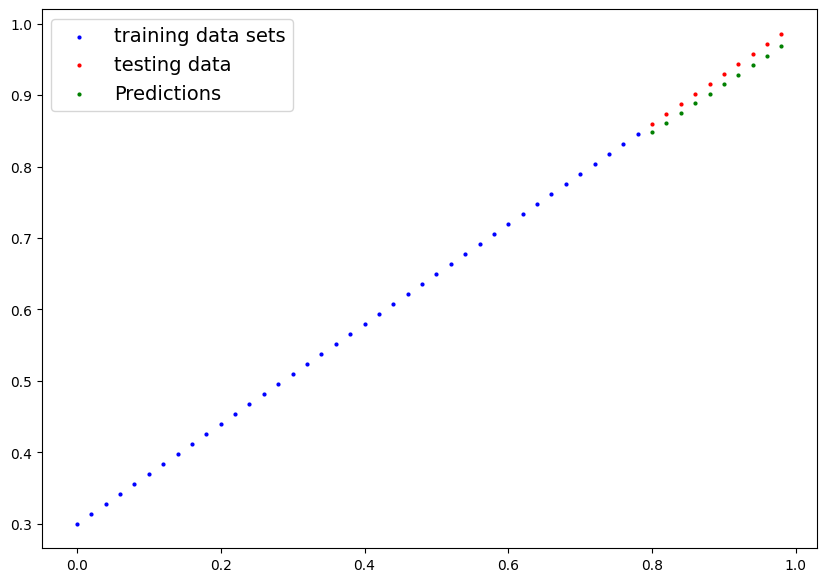

In [28]:
plot_prediction(predictions=y_pred.cpu())

### save model

In [29]:
from pathlib import Path
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "pytorch_workflow_model1.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME
print(f"saving model path :", {MODEL_SAVE_PATH})
torch.save(obj=model1.state_dict(), f=MODEL_SAVE_PATH)

saving model path : {PosixPath('models/pytorch_workflow_model1.pth')}


In [30]:
model1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6691]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3130], device='cuda:0'))])

### loading model

In [31]:
### loading model
loaded_model1= LinearRegressionModelV2()
loaded_model1.load_state_dict(torch.load(MODEL_SAVE_PATH))
loaded_model1.to(device)

LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [33]:
next(loaded_model1.parameters()).device

device(type='cuda', index=0)

In [34]:
## evaluate model
loaded_model1.eval()
with torch.inference_mode():
  loaded_model1_preds = loaded_model1(X_test)
y_pred == loaded_model1_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')